In [1]:
from president.experiments.positional_dynamics.run_loader import *

## Loading the data

In [2]:
trial_id = "5_SSA"
games = load_game_log(f"run{trial_id}.csv")
players = to_player_frame(games)
games

,trial_id,game_index,num_players,president_id,vice_president_id,vice_scum_id,scum_id,winner_ids,hand_strength_prediction
0,5_SSA,0,5,<NA>,<NA>,<NA>,<NA>,"[1, 3, 0, 2, 4]","[1.2987460529306545, -1.302385972524947, 1.316..."
1,5_SSA,0,5,<NA>,<NA>,<NA>,<NA>,"[2, 4, 1, 0, 3]","[0.5597349008600836, -0.17621398438336314, 1.0..."
2,5_SSA,0,5,<NA>,<NA>,<NA>,<NA>,"[4, 1, 0, 2, 3]","[0.9462047365539197, -0.44288487828165646, 1.1..."
3,5_SSA,1,5,1,3,2,4,"[1, 3, 2, 4, 0]","[0.503795452191863, 0.3570716599851779, -1.262..."
4,5_SSA,1,5,2,4,0,3,"[2, 3, 4, 0, 1]","[1.0365477804220942, -0.07406362500345413, -0...."
...,...,...,...,...,...,...,...,...,...
29995,5_SSA,9998,5,3,1,0,2,"[2, 3, 0, 1, 4]","[1.315232278407568, -1.5053520980107709, 0.596..."
29996,5_SSA,9998,5,4,1,3,0,"[4, 2, 3, 0, 1]","[1.7388706875402602, 1.5057830140867312, -0.70..."
29997,5_SSA,9999,5,2,1,4,0,"[3, 4, 2, 0, 1]","[0.5573995465261034, -1.155898834009428, -0.42..."
29998,5_SSA,9999,5,2,3,1,4,"[2, 3, 0, 1, 4]","[0.6636496187316578, 0.7943990531113008, 1.688..."


In [3]:
players

,trial_id,game_index,num_players,player_id,seat_offset,role_this_game,finish_rank,performance,hand_strength_prediction
0,5_SSA,0,5,0,<NA>,commoner,2,0,1.316714
1,5_SSA,0,5,1,<NA>,commoner,0,2,1.298746
2,5_SSA,0,5,2,<NA>,commoner,3,-1,-0.805426
3,5_SSA,0,5,3,<NA>,commoner,1,1,-1.302386
4,5_SSA,0,5,4,<NA>,commoner,4,-2,-1.449323
...,...,...,...,...,...,...,...,...,...
149995,5_SSA,9999,5,0,1,vice_scum,3,-1,0.485263
149996,5_SSA,9999,5,1,2,scum,1,1,-1.007977
149997,5_SSA,9999,5,2,3,vice_president,4,-2,-1.568312
149998,5_SSA,9999,5,3,4,commoner,2,0,-0.831001


# Main columns 

In [4]:
players[players.player_id == 1][
    ["seat_offset",
    "role_this_game",
     "hand_strength_prediction",
     "finish_rank"]
]

,seat_offset,role_this_game,hand_strength_prediction,finish_rank
1,<NA>,commoner,1.298746,0
6,<NA>,commoner,1.052913,2
11,<NA>,commoner,-0.442885,1
16,0,president,0.503795,0
21,4,commoner,-0.166814,4
...,...,...,...,...
149976,3,vice_president,1.381490,3
149981,2,vice_president,-0.054467,4
149986,4,vice_president,-0.142601,4
149991,4,vice_scum,-0.273491,3


## Derived columns

In [5]:
def role_value(role):
    if role == "president":
        return 2
    if role == "vice_president":
        return 1
    if role == "vice_scum":
        return -1
    if role == "scum":
        return -2
    if role == "commoner":
        return 0

In [6]:
players["current_role_value"] = players["role_this_game"].apply(role_value)

In [7]:
players[players.player_id==1][["role_this_game", "current_role_value"]]

,role_this_game,current_role_value
1,commoner,0
6,commoner,0
11,commoner,0
16,president,2
21,commoner,0
...,...,...
149976,vice_president,1
149981,vice_president,1
149986,vice_president,1
149991,vice_scum,-1


In [8]:
players["role_value_change"] = players.performance - players.current_role_value

## Linear models

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = players[players["game_index"]>1][["current_role_value"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(role)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"current_role_value coefficient: {model.coef_[0]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(role)

Intercept: 0.000
current_role_value coefficient: 0.325
R²: 0.106


In [10]:
X = players[players["game_index"]>1][["seat_offset"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset)

Intercept: 0.609
seat_offset coefficient: -0.305
R²: 0.093


In [11]:
X = players[players["game_index"]>1][["hand_strength_prediction"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"hand_strength_prediction coefficient: {model.coef_[0]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(hand_strength)

Intercept: 0.009
hand_strength_prediction coefficient: 0.729
R²: 0.285


In [12]:
X = players[players["game_index"]>1][["seat_offset", "current_role_value"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset, role)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"current_role_value coefficient: {model.coef_[1]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset, role)

Intercept: 0.347
seat_offset coefficient: -0.173
current_role_value coefficient: 0.222
R²: 0.125


In [13]:
X = players[players["game_index"]>1][["seat_offset", "hand_strength_prediction"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset, hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"hand_strength coefficient: {model.coef_[1]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset, hand_strength)

Intercept: 0.428
seat_offset coefficient: -0.210
hand_strength coefficient: 0.674
R²: 0.328


In [14]:
X = players[players["game_index"]>1][["current_role_value", "hand_strength_prediction"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(role, hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"role coefficient: {model.coef_[0]:.3f}")
print(f"hand_strength coefficient: {model.coef_[1]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(role, hand_strength)

Intercept: 0.008
role coefficient: 0.197
hand_strength coefficient: 0.658
R²: 0.321


In [15]:
X = players[players["game_index"]>1][["seat_offset", "hand_strength_prediction", "current_role_value"]]
y = players[players["game_index"]>1]["performance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("performance = f(seat_offset, hand_strength)\n")
print(f"Intercept: {model.intercept_:.3f}")
print(f"seat_offset coefficient: {model.coef_[0]:.3f}")
print(f"hand_strength coefficient: {model.coef_[1]:.3f}")
print(f"current_role_value coefficient: {model.coef_[2]:.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")

performance = f(seat_offset, hand_strength)

Intercept: 0.303
seat_offset coefficient: -0.148
hand_strength coefficient: 0.650
current_role_value coefficient: 0.111
R²: 0.335


Seat offset shows a moderate correlation with a model trained on only it as input has an $r^2$ of 0.155.
Both hand_strength and current role are very correlated with performance as expected, together they dont add much more information since a high role and good hand strength are correlated. 

## Mean performance(seat_offset, role)

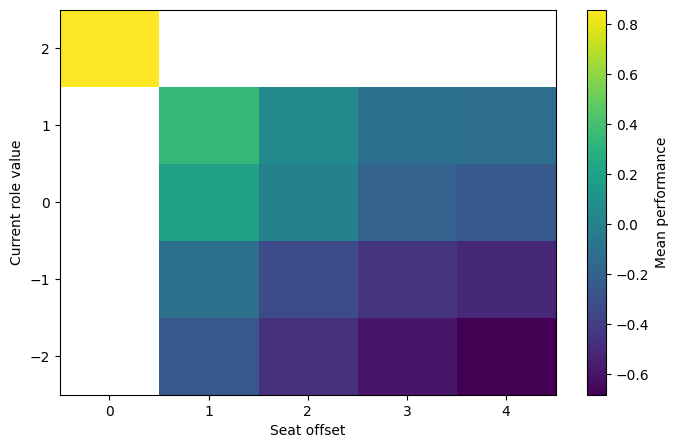

In [16]:
seat_offsets = np.unique(players[players.game_index>1]["seat_offset"])
role_values = np.unique(players[players.game_index>1]["current_role_value"] )

mean_rank = np.full(
    (len(role_values), len(seat_offsets)),
    np.nan,
)

for i, role in enumerate(role_values):
    for j, seat in enumerate(seat_offsets):
        mask = (
            (players[players.game_index>1]["seat_offset"] == seat) &
            (players[players.game_index>1]["current_role_value"] == role)
        )

        if np.any(mask):
            mean_rank[i, j] = players[players.game_index>1]["performance"][mask].mean()

plt.figure(figsize=(8, 5))

plt.imshow(
    mean_rank,
    origin="lower",
    aspect="auto",
    extent=[
        seat_offsets.min() - 0.5,
        seat_offsets.max() + 0.5,
        role_values.min() - 0.5,
        role_values.max() + 0.5,
    ],
)

plt.colorbar(label="Mean performance")
plt.xlabel("Seat offset")
plt.ylabel("Current role value")
plt.xticks(seat_offsets)
plt.yticks(role_values)

plt.show()

seat_offset=0 means president, which means its only current role value is 2, which has high average performance.
A slight tendency can be seen of seat_offset=1 having greater mean performance than other offsets

## Hand strength predictor statistics

In [17]:
def hand_strength_stats(performance):
    mean = players[(players.game_index>1) & (players.performance==performance)]["hand_strength_prediction"].mean()
    std = players[(players.game_index>1) & (players.performance==performance)]["hand_strength_prediction"].std()
    print(f"Performance:{performance}\tPrediction: mean: {mean:.2f}\tstd:{std:.2f}")

for performance in np.sort(players.performance.unique()):
    hand_strength_stats(performance)


Performance:-2	Prediction: mean: -0.71	std:0.82
Performance:-1	Prediction: mean: -0.42	std:0.88
Performance:0	Prediction: mean: -0.12	std:0.91
Performance:1	Prediction: mean: 0.30	std:0.91
Performance:2	Prediction: mean: 0.89	std:0.83


The hand strength predictor successfully trained and its outputs generally correlate with game outcome

## Distribution of winners

/tmp/ipykernel_623073/2064954379.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  presidents = players[players.game_index>1][players.performance==2]


Text(0, 0.5, 'Count')

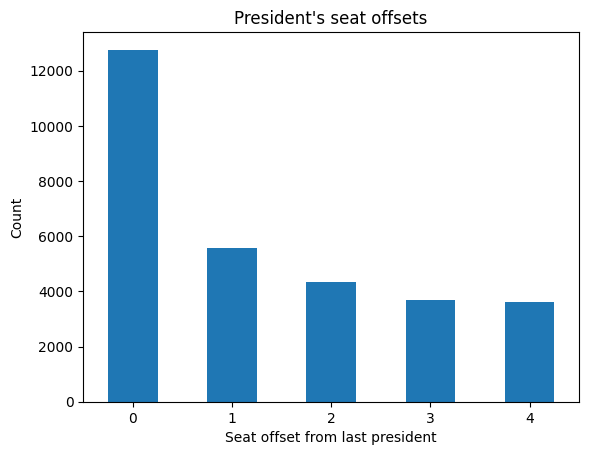

In [18]:
presidents = players[players.game_index>1][players.performance==2]
counts = presidents.seat_offset.value_counts(sort=False).sort_index()

ax = counts.plot(kind="bar")
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("President's seat offsets")
ax.set_xlabel("Seat offset from last president")
ax.set_ylabel("Count")

## Change in presidents

/tmp/ipykernel_623073/1697880563.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_presidents = players[players.game_index>1][


Text(0, 0.5, 'Count')

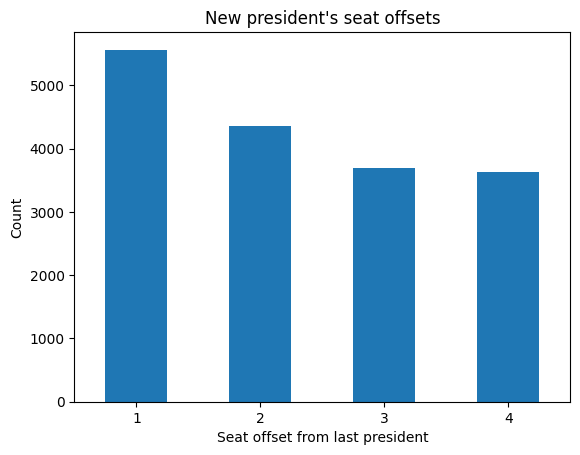

In [19]:
new_presidents = players[players.game_index>1][
    (players.performance==2) &
    (players.current_role_value<2)
]
counts = new_presidents.seat_offset.value_counts(sort=False).sort_index()

ax = counts.plot(kind="bar")
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("New president's seat offsets")
ax.set_xlabel("Seat offset from last president")
ax.set_ylabel("Count")

Players seated one seat after the president seem more likely to become the new president, but this tendency is modest, to make this tendency rigurous we make a statistical analysis

/tmp/ipykernel_623073/1004368798.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_presidents = players[players.game_index > 1][


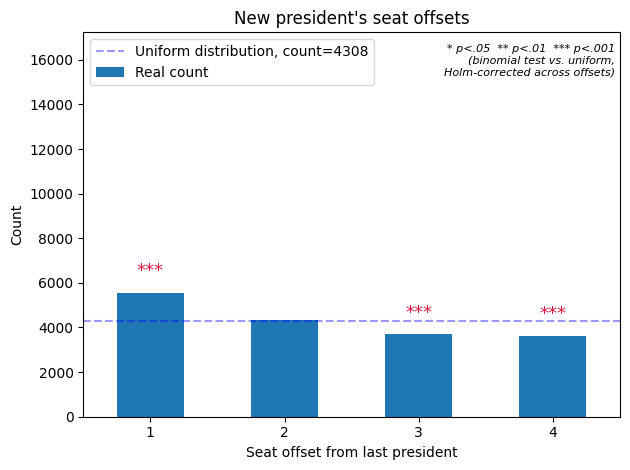

In [20]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

new_presidents = players[players.game_index > 1][
    (players.performance == 2) & (players.current_role_value < 2)
]

counts = new_presidents.seat_offset.value_counts(sort=False).sort_index()

n = counts.sum()
k = len(counts)
p_null = 1 / k  # equal probability per offset under H0

# per-offset exact binomial test vs the uniform null
pvals = [stats.binomtest(c, n, p_null, alternative="two-sided").pvalue for c in counts]

# multiple-comparison correction across the k offsets tested
reject, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method="holm")

ax = counts.plot(kind="bar", label="Real count")
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("New president's seat offsets")
ax.set_xlabel("Seat offset from last president")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.sum())
ax.axhline(
    y=counts.sum()/counts.shape[0],
    color='b',
    linestyle='--',
    alpha = 0.4,
    label=f"Uniform distribution, count={counts.sum()/counts.shape[0]:.0f}"
)

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

ymax = counts.max()
for i, p_adj in enumerate(pvals_adj):
    s = stars(p_adj)
    if s:
        ax.text(i, counts.iloc[i] + ymax * 0.1, s,
                ha="center", va="bottom", fontsize=13, color="crimson")

ax.text(
    0.99, 0.97,
    "* p<.05  ** p<.01  *** p<.001\n(binomial test vs. uniform,\nHolm-corrected across offsets)",
    transform=ax.transAxes, ha="right", va="top", fontsize=8, style="italic",
)

ax.legend()
plt.tight_layout()
plt.show()


We can see seat_offset = 1 advantage is statistically significant, we also see some of the rest of the seats disadvantaged as would be expected to compensate.

Interestingly, the last seat doesnt seem to be disadvantaged with respect to the uniform, according to our hypothesis, the last seat is disadvantaged due to playing its biggest cards right before president, meaning his high cards are likely to be lost.

One possible explanation to this is a back-and-forth tendency, where when presidents lose, they are likely to go down to vice-president, and its likely that they lost to the player at seat_offset=1, meaning now they are the player at seat_offset=n-1 which disadvantages them, but not enough to outweigh their role as vice-president 

In [21]:
losing_presidents = players[
    (players.game_index > 1) &
    (players.current_role_value == 2) &
    (players.performance < 2)
]

losing_presidents.performance.value_counts()

performance
1     7285
0     4794
-1    3191
-2    1962
Name: count, dtype: Int64

Indeed, presidents overwhelmingly become vice-presidents after losing

role_this_game  scum  vice_scum  commoner  vice_president
seat_offset                                              
1                518        799      1390            2857
2                781        865      1465            1240
3                787        897      1092             916
4                770        779      1104             972


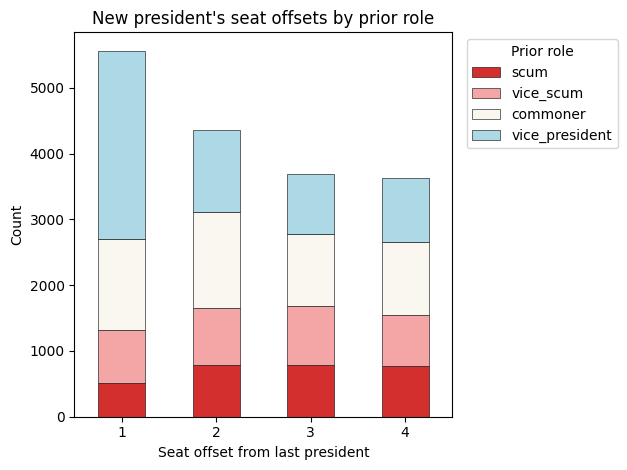

In [22]:
role_order = ["scum", "vice_scum", "commoner", "vice_president"]  # bottom -> top of stack
role_colors = {
    "scum":       "#D32F2F",  # red
    "vice_scum":  "#F4A6A6",  # light red
    "commoner":   "#FAF6F0",  # off-white
    "vice_president":       "#ADD8E6",  # light blue
}

new_presidents = players[
    (players.game_index > 1) &
    (players.performance == 2) &
    (players.current_role_value < 2)
]

pivot = (
    new_presidents
    .groupby(["seat_offset", "role_this_game"])
    .size()
    .unstack("role_this_game")
    .reindex(columns=role_order)  # forces column order = stack order
    .sort_index()
)
print(pivot)

totals = pivot.sum(axis=1)

ax = pivot.plot(
    kind="bar", stacked=True,
    color=[role_colors[r] for r in role_order],
    edgecolor="black", linewidth=0.4,
)
ax.tick_params(axis="x", labelrotation=0)
ax.set_title("New president's seat offsets by prior role")
ax.set_xlabel("Seat offset from last president")
ax.set_ylabel("Count")
ax.legend(title="Prior role", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Its not clear whether the lack of disadvantage in the last seat is due to overrepresentation of vice-presidents retaking the rule or its due to something else 